In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import matplotlib.pyplot as plt

In [ ]:
x = np.array([1, 2, 3]).reshape(-1, 1)
y1 = np.array([2, 4, 6])
y2 = np.array([3, 5, 7])

print("Input x:", x.flatten())
print("Target y1:", y1)
print("Target y2:", y2)

Input x: [1 2 3]
Target y1: [2 4 6]
Target y2: [3 5 7]


--- Multivariate Linear Regression ---
Coefficients (for y1, y2): [2. 2.]
Intercepts (for y1, y2): [8.8817842e-16 1.0000000e+00]

--- Performance Metrics (Multivariate Model - for y1) ---
Mean Squared Error (MSE): 0.00
Mean Absolute Error (MAE): 0.00
R-squared (R2): 1.00
Adjusted R-squared: 1.00

--- Performance Metrics (Multivariate Model - for y2) ---
Mean Squared Error (MSE): 0.00
Mean Absolute Error (MAE): 0.00
R-squared (R2): 1.00
Adjusted R-squared: 1.00


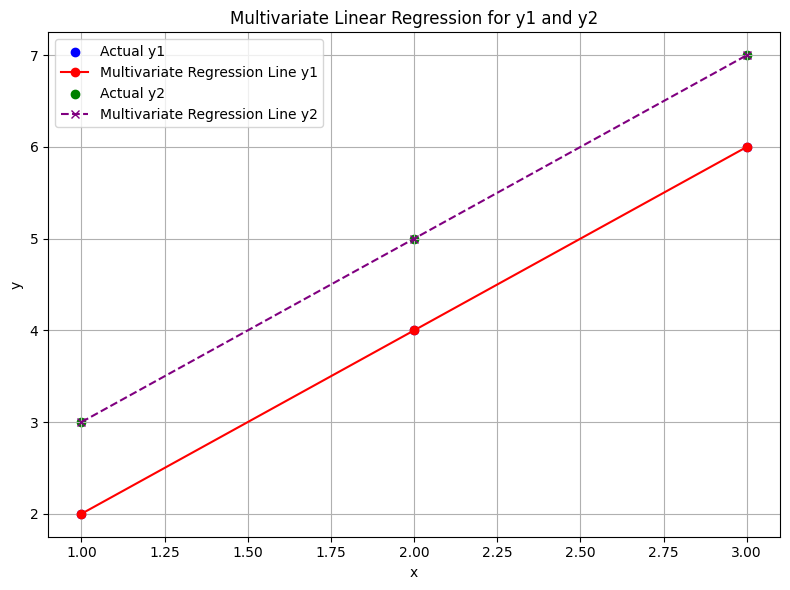

In [ ]:
Y = np.column_stack((y1, y2))

multivariate_model = LinearRegression()
multivariate_model.fit(x, Y)

multivariate_pred = multivariate_model.predict(x)

multivariate_y1_pred = multivariate_pred[:, 0]
multivariate_y2_pred = multivariate_pred[:, 1]

print("--- Multivariate Linear Regression ---")
print(f"Coefficients (for y1, y2): {multivariate_model.coef_.flatten()}")
print(f"Intercepts (for y1, y2): {multivariate_model.intercept_}")

n_samples = x.shape[0]
n_features = x.shape[1]

mse_y1 = mean_squared_error(y1, multivariate_y1_pred)
mae_y1 = mean_absolute_error(y1, multivariate_y1_pred)
r2_y1 = r2_score(y1, multivariate_y1_pred)
adjusted_r2_y1 = 1 - (1 - r2_y1) * (n_samples - 1) / (n_samples - n_features - 1)

print("\n--- Performance Metrics (Multivariate Model - for y1) ---")
print(f"Mean Squared Error (MSE): {mse_y1:.2f}")
print(f"Mean Absolute Error (MAE): {mae_y1:.2f}")
print(f"R-squared (R2): {r2_y1:.2f}")
print(f"Adjusted R-squared: {adjusted_r2_y1:.2f}")

# Performance metrics for y2
mse_y2 = mean_squared_error(y2, multivariate_y2_pred)
mae_y2 = mean_absolute_error(y2, multivariate_y2_pred)
r2_y2 = r2_score(y2, multivariate_y2_pred)
adjusted_r2_mv_y2 = 1 - (1 - r2_y2) * (n_samples - 1) / (n_samples - n_features - 1)

print("\n--- Performance Metrics (Multivariate Model - for y2) ---")
print(f"Mean Squared Error (MSE): {mse_y2:.2f}")
print(f"Mean Absolute Error (MAE): {mae_y2:.2f}")
print(f"R-squared (R2): {r2_y2:.2f}")
print(f"Adjusted R-squared: {adjusted_r2_y2:.2f}")

plt.figure(figsize=(8, 6))

plt.scatter(x, y1, color='blue', label='Actual y1')
plt.plot(x, multivariate_y1_pred, color='red', linestyle='-', marker='o', label='Multivariate Regression Line y1')

plt.scatter(x, y2, color='green', label='Actual y2')
plt.plot(x, multivariate_y2_pred, color='purple', linestyle='--', marker='x', label='Multivariate Regression Line y2')

plt.title('Multivariate Linear Regression for y1 and y2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

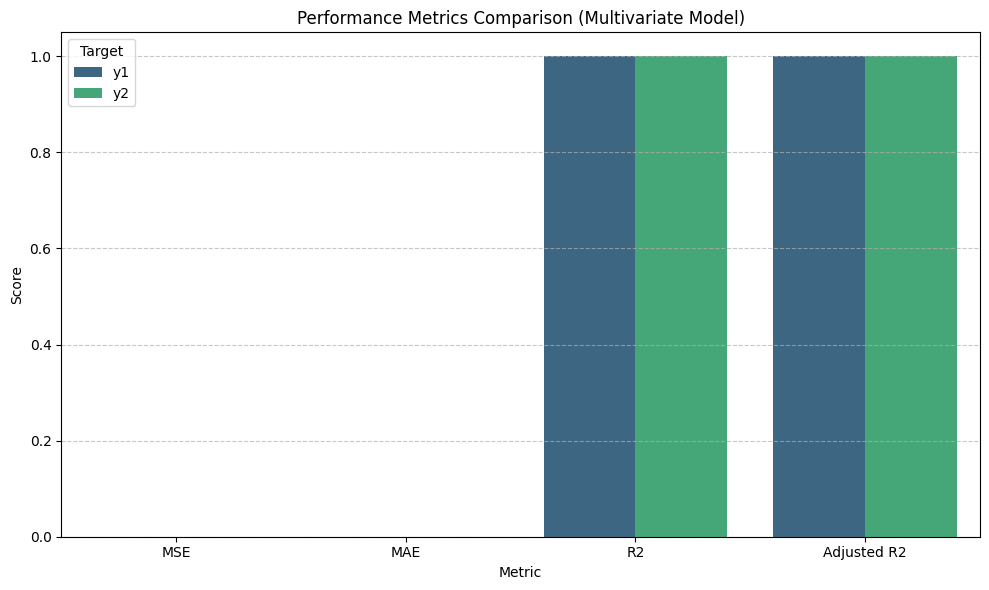

In [ ]:
import pandas as pd
import seaborn as sns


metrics_data = {
    'Metric': ['MSE', 'MAE', 'R2', 'Adjusted R2', 'MSE', 'MAE', 'R2', 'Adjusted R2'],
    'Target': ['y1', 'y1', 'y1', 'y1', 'y2', 'y2', 'y2', 'y2'],
    'Value': [
        mse_y1, mae_y1, r2_y1, adjusted_r2_y1,
        mse_y2, mae_y2, r2_y2, adjusted_r2_y2
    ]
}

df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))

sns.barplot(x='Metric', y='Value', hue='Target', data=df_metrics, palette='viridis')
plt.title('Performance Metrics Comparison (Multivariate Model)')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()